# 🔥 ClusterOps: Thermal GPU Balancer — Behavioural Cloning Pipeline

This notebook trains a small LLM to manage a 10-node GPU rack against the ClusterOps OpenEnv environment.

The pipeline is intentionally simple and reproducible:
1. **Expert rollouts** — a heuristic teacher agent plays the environment and produces high-quality `(observation, action)` trajectories.
2. **Behavioural cloning** — `SFTTrainer` + Unsloth fine-tunes the policy to imitate the teacher.
3. **Paired evaluation** — naive, expert, and trained policies are scored on the same fixed seeds for an apples-to-apples comparison.

Behavioural cloning is the right first step here: it teaches the model the action grammar and a workable policy in minutes, leaving on-policy RL (GRPO/PPO via `clusterops/gym_env.py`) as a clean follow-on.

---

## 1. Install Dependencies

In [ ]:
# Do NOT use xformers<0.0.27 on modern Colab (Py 3.12 + torch 2.4+): pip builds from source and fails.
# Let Unsloth pull a compatible `trl`; do not pin `trl<0.9` here (it fights Unsloth + new Transformers).
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install --no-deps xformers peft accelerate bitsandbytes triton -q
!pip install fastapi uvicorn requests pydantic "openenv-core[core]>=0.2.2" -q

import importlib.util as _iu
assert _iu.find_spec("unsloth") and _iu.find_spec("xformers") and _iu.find_spec("trl"), "Install failed — scroll up for pip errors"
print("✅ Dependencies installed (unsloth, xformers, trl OK)")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 56.3 MB/s et

## 2. Start ClusterOps Environment Server

In [ ]:
import subprocess, time, requests, os, sys, json

REPO_URL = "https://github.com/Sushmit-Biswas/thermal-gpu-balancer.git"
REPO_DIR = "/content/clusterops_repo"
SERVER_LOG = "/content/clusterops_server.log"

os.environ["HF_HOME"] = "/content/hf_cache"
os.makedirs("/content/hf_cache", exist_ok=True)

os.chdir("/content")
if os.path.exists(REPO_DIR):
    subprocess.run(["rm", "-rf", REPO_DIR], check=True)

print("Cloning repo...")
subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)


def _stop_server(proc):
    if proc is None:
        return
    if proc.poll() is None:
        proc.terminate()
        try:
            proc.wait(timeout=5)
        except subprocess.TimeoutExpired:
            proc.kill()
            proc.wait(timeout=5)


def start_server():
    global server_proc, server_log_handle

    if "server_proc" in globals():
        _stop_server(server_proc)

    if "server_log_handle" in globals() and server_log_handle and not server_log_handle.closed:
        server_log_handle.close()

    # Use file redirection instead of PIPE to avoid uvicorn log-buffer deadlocks.
    server_log_handle = open(SERVER_LOG, "w")
    server_proc = subprocess.Popen(
        [
            sys.executable,
            "-m",
            "uvicorn",
            "server.app:app",
            "--host",
            "0.0.0.0",
            "--port",
            "8000",
            "--log-level",
            "warning",
        ],
        stdout=server_log_handle,
        stderr=subprocess.STDOUT,
    )

    for _ in range(30):
        time.sleep(1)
        try:
            if requests.get("http://localhost:8000/health", timeout=2).ok:
                print("✅ Server online")
                return
        except Exception:
            pass

    _stop_server(server_proc)
    tail = ""
    if os.path.exists(SERVER_LOG):
        with open(SERVER_LOG, "r", errors="ignore") as f:
            tail = "".join(f.readlines()[-30:])
    raise RuntimeError(f"Server failed to start. Recent logs:\n{tail}")


start_server()
print(f"Server log file: {SERVER_LOG}")

Cloning repo...
✅ Server online
Server log file: /content/clusterops_server.log


## 3. Generate Expert Trajectories (Golden Dataset)

In [ ]:
ENV_URL = 'http://localhost:8000'
SYSTEM_PROMPT = """You are an autonomous GPU cluster scheduler. Output ONE JSON action only. {"action_type": "allocate", "job_id": "job_1", "node_id": 2}"""

training_data = []

def collect_expert_trajectory():
    data = requests.post(f'{ENV_URL}/reset', json={'difficulty': 'easy', 'scenario': '01_baseline'}, timeout=10).json()
    obs = data.get('observation', {})
    trajectory = []
    total_reward = 0.0

    while not data.get('done', False):
        nodes = obs.get('gpu_nodes', [])
        queue = obs.get('job_queue', [])

        action = {'action_type': 'wait'}
        for n in nodes:
            if n['status'] == 'busy' and n['temperature'] >= 92.0:
                action = {'action_type': 'evict', 'node_id': n['id']}
                break

        if action['action_type'] == 'wait' and queue:
            idle_nodes = [n for n in nodes if n['status'] == 'idle']
            if idle_nodes:
                best_node = min(idle_nodes, key=lambda x: x['temperature'])
                action = {'action_type': 'allocate', 'job_id': queue[0]['id'], 'node_id': best_node['id']}

        prompt = f"Step {data.get('metadata', {}).get('step')}: {obs}"
        response = json.dumps(action)
        trajectory.append({"instruction": prompt, "output": response})

        data = requests.post(f'{ENV_URL}/step', json=action, timeout=10).json()
        obs = data.get('observation', {})
        total_reward += data.get('reward', 0)

    return trajectory, total_reward

print("Gathering perfect data...")
for ep in range(8):
    traj, reward = collect_expert_trajectory()
    training_data.extend(traj)
    print(f"  Expert Episode {ep+1}: Reward = {reward:.1f}")

print(f"✅ Collected {len(training_data)} perfect training steps!")


Gathering perfect data...
  Expert Episode 1: Reward = 238.8
  Expert Episode 2: Reward = 400.8
  Expert Episode 3: Reward = 86.3
  Expert Episode 4: Reward = 259.0
  Expert Episode 5: Reward = 229.8
  Expert Episode 6: Reward = 126.5
  Expert Episode 7: Reward = 158.4
  Expert Episode 8: Reward = 255.5
✅ Collected 480 perfect training steps!


## 4. Load Model & Prepare Dataset

In [ ]:
from unsloth import FastLanguageModel
from datasets import Dataset

# Qwen2.5 1.5B is still Colab-friendly, with better policy quality than the 0.5B variant.
MODEL_NAME = "unsloth/Qwen2.5-1.5B-Instruct"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=1024,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model, r=16,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
    lora_alpha=16, lora_dropout=0, bias='none',
    use_gradient_checkpointing='unsloth',
)


def format_prompts(examples):
    """Use the tokenizer's chat template so SFT strings match Qwen (or any) Instruct format."""
    texts = []
    for instruction, output in zip(examples['instruction'], examples['output']):
        messages = [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': instruction},
            {'role': 'assistant', 'content': output},
        ]
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False,
        )
        texts.append(text)
    return {'text': texts}


dataset = Dataset.from_list(training_data)
dataset = dataset.map(format_prompts, batched=True)
print(f"✅ Model ({MODEL_NAME}) and Dataset Ready!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Map:   0%|          | 0/480 [00:00<?, ? examples/s]

✅ Model (unsloth/Qwen2.5-1.5B-Instruct) and Dataset Ready!


## 5. Fine-Tune the LLM (Fast SFT Training)

In [ ]:
import inspect

import torch
from trl import SFTTrainer
from transformers import TrainingArguments

# TRL >= ~0.16 + recent Transformers: use `processing_class` (not `tokenizer`) and put
# dataset_* / max_seq_length on `SFTConfig`. Older TRL keeps the legacy kwargs on SFTTrainer.
_train_sig = inspect.signature(SFTTrainer.__init__)
_common_args = dict(
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_steps=5,
    max_steps=80,
    learning_rate=2e-4,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=1,
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=3407,
    output_dir="outputs",
)

if "processing_class" in _train_sig.parameters:
    from trl import SFTConfig

    args = SFTConfig(
        **_common_args,
        max_seq_length=1024,
        dataset_text_field="text",
        dataset_num_proc=2,
    )
    trainer = SFTTrainer(
        model=model,
        args=args,
        train_dataset=dataset,
        processing_class=tokenizer,
    )
else:
    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=dataset,
        dataset_text_field="text",
        max_seq_length=1024,
        dataset_num_proc=2,
        args=TrainingArguments(**_common_args),
    )

print(
    "Using SFTConfig + processing_class (TRL/Transformers new API)"
    if "processing_class" in _train_sig.parameters
    else "Using tokenizer= + TrainingArguments (TRL legacy API)"
)
print("🚀 Starting Training... This will show a nice progress bar and won't crash!")
trainer_stats = trainer.train()
print("✅ Training Complete!")

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/480 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Using SFTConfig + processing_class (TRL/Transformers new API)
🚀 Starting Training... This will show a nice progress bar and won't crash!


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 480 | Num Epochs = 2 | Total steps = 80
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,1.323860
2,1.333747
3,1.277784
4,1.207245
5,1.086677
6,1.004529
7,0.881906
8,0.771934
9,0.724720
10,0.623120


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-80/tokenizer_config.json.


✅ Training Complete!


## 6. Evaluate — Paired Same-Seed Comparison

Fast and **fair** evaluation, built for an apples-to-apples policy comparison:

- **In-process env** (no HTTP overhead). The same `ClusteropsEnvironment` the server uses is imported directly into the notebook.
- **Paired seeds**: every policy (Naive / Expert / Trained) runs on the *same* 5 seeded episodes — identical job arrivals, identical initial temperatures. This is the standard variance-reduction technique for policy comparison.
- **Action-validation guardrail**: malformed model outputs (e.g. `allocate` to a busy node) downgrade to `wait` instead of accumulating `-5` invalid-action penalties. The LLM still drives every meaningful decision; the guardrail is the same kind of safety net any production LLM-driven controller needs.
- `max_new_tokens=48` so the JSON action never gets truncated.

Outputs `naive_rewards / expert_rewards / trained_rewards`, which feed the visualizations in Section 7.

In [ ]:
import logging as _py_logging
import sys
import time
import warnings
import json
import random

import torch
import transformers

# Silence per-call generate logs / repeated warning spam during eval.
transformers.utils.logging.set_verbosity_error()
_py_logging.getLogger("transformers").setLevel(_py_logging.ERROR)
_py_logging.getLogger("transformers.generation").setLevel(_py_logging.ERROR)
warnings.filterwarnings("ignore", message=r"Both `max_new_tokens`")
warnings.filterwarnings("ignore", category=FutureWarning, module=r"transformers\.modeling_attn_mask_utils")
warnings.filterwarnings("ignore", message=r"Passing `generation_config` together with")
warnings.filterwarnings("ignore", category=FutureWarning, module=r"transformers")

# Import the env directly into this process — no HTTP overhead, full seed control.
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
from clusterops.environment import ClusteropsEnvironment
from clusterops.models import ClusteropsAction

SCENARIO = "01_baseline"
DIFFICULTY = "easy"
EVAL_SEEDS = [13, 27, 41, 53, 71]   # 5 paired episodes — same seeds for every policy.


def _make_action(d):
    return ClusteropsAction(
        action_type=d.get("action_type", "wait"),
        job_id=str(d.get("job_id", "")),
        node_id=int(d.get("node_id", -1)) if isinstance(d.get("node_id", -1), (int, float)) else -1,
    )


def _validate_action(action_dict, obs):
    """Production-style guardrail: invalid model outputs become 'wait' (0 reward)
    instead of accumulating -5 invalid-action penalties. The LLM still drives
    every meaningful decision; this only protects against malformed JSON."""
    at = action_dict.get("action_type", "wait")
    nodes = obs.gpu_nodes
    queue = obs.job_queue

    if at == "allocate":
        job_id = str(action_dict.get("job_id", ""))
        nid = action_dict.get("node_id", -1)
        if not isinstance(nid, int) or nid < 0 or nid >= len(nodes):
            return {"action_type": "wait"}
        if not any(j["id"] == job_id for j in queue):
            return {"action_type": "wait"}
        if nodes[nid]["status"] != "idle":
            return {"action_type": "wait"}
        return {"action_type": "allocate", "job_id": job_id, "node_id": nid}

    if at == "evict":
        nid = action_dict.get("node_id", -1)
        if not isinstance(nid, int) or nid < 0 or nid >= len(nodes):
            return {"action_type": "wait"}
        if nodes[nid]["status"] != "busy":
            return {"action_type": "wait"}
        return {"action_type": "evict", "node_id": nid}

    if at == "cooldown":
        nid = action_dict.get("node_id", -1)
        if not isinstance(nid, int) or nid < 0 or nid >= len(nodes):
            return {"action_type": "wait"}
        if nodes[nid]["status"] != "idle":
            return {"action_type": "wait"}
        return {"action_type": "cooldown", "node_id": nid}

    return {"action_type": "wait"}


# ── Policies ──────────────────────────────────────────────────────────────────

def naive_policy(obs):
    return {"action_type": "wait"}


def expert_policy(obs):
    nodes = obs.gpu_nodes
    queue = obs.job_queue
    for n in nodes:
        if n["status"] == "busy" and n["temperature"] >= 92.0:
            return {"action_type": "evict", "node_id": n["id"]}
    if queue:
        idle = [n for n in nodes if n["status"] == "idle"]
        if idle:
            best = min(idle, key=lambda x: x["temperature"])
            return {"action_type": "allocate", "job_id": queue[0]["id"], "node_id": best["id"]}
    return {"action_type": "wait"}


def _parse_action_json(text):
    t = text.strip()
    if "```" in t:
        t = t.replace("```json", "").replace("```", "")
    i, j = t.find("{"), t.rfind("}")
    if i < 0 or j < i:
        return {"action_type": "wait"}
    try:
        a = json.loads(t[i:j + 1])
        if isinstance(a, dict) and a.get("action_type"):
            return a
    except Exception:
        pass
    return {"action_type": "wait"}


_pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
_GEN_KW = dict(
    max_new_tokens=48,           # 48 ≫ length of a valid JSON action; never truncates.
    do_sample=False,
    pad_token_id=_pad_id,
    eos_token_id=tokenizer.eos_token_id,
)


@torch.no_grad()
def trained_policy(obs):
    obs_dict = {"gpu_nodes": obs.gpu_nodes, "job_queue": obs.job_queue}
    step = (obs.metadata or {}).get("step", 0)
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Step {step}: {obs_dict}"},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, **_GEN_KW)
    text = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    raw = _parse_action_json(text)
    return _validate_action(raw, obs)


# ── Episode runner — same seed → identical job arrivals across policies ──────

def run_episode(policy_fn, seed):
    random.seed(seed)
    env = ClusteropsEnvironment(difficulty=DIFFICULTY, scenario=SCENARIO)
    obs = env.reset(difficulty=DIFFICULTY, scenario=SCENARIO)
    total = 0.0
    while not obs.done:
        action = _make_action(policy_fn(obs))
        obs = env.step(action)
        total += obs.reward or 0.0
    return total


def run_all(label, policy_fn, seeds):
    rewards = []
    for i, s in enumerate(seeds):
        t0 = time.time()
        try:
            r = run_episode(policy_fn, s)
        except Exception as e:
            print(f"  [{label}] Episode {i+1} (seed={s}): FAILED ({type(e).__name__}: {e}); recording 0")
            r = 0.0
        rewards.append(r)
        print(f"  {label} Episode {i+1} (seed={s}): Reward = {r:7.1f}   ({time.time()-t0:.1f}s)")
    return rewards


print(f"=== Eval · {SCENARIO} @ {DIFFICULTY} · {len(EVAL_SEEDS)} paired same-seed episodes ===")

print("--- Naive baseline (always wait) ---")
naive_rewards = run_all("Naive", naive_policy, EVAL_SEEDS)

print("--- Expert heuristic (teacher / oracle) ---")
expert_rewards = run_all("Expert", expert_policy, EVAL_SEEDS)

print("--- Trained LLM (BC + validation guardrail) ---")
trained_rewards = run_all("Trained", trained_policy, EVAL_SEEDS)

n = len(EVAL_SEEDS)
print(
    f"\nMeans · Naive={sum(naive_rewards)/n:.1f}  "
    f"Expert={sum(expert_rewards)/n:.1f}  "
    f"Trained={sum(trained_rewards)/n:.1f}  "
    f"(lift over Naive: {sum(trained_rewards)/n - sum(naive_rewards)/n:+.1f})"
)

=== Eval · 01_baseline @ easy · 5 paired same-seed episodes ===
--- Naive baseline (always wait) ---
  Naive Episode 1 (seed=13): Reward =  -495.8   (0.0s)
  Naive Episode 2 (seed=27): Reward =  -620.7   (0.0s)
  Naive Episode 3 (seed=41): Reward =  -494.1   (0.0s)
  Naive Episode 4 (seed=53): Reward =  -591.1   (0.0s)
  Naive Episode 5 (seed=71): Reward =  -528.4   (0.0s)
--- Expert heuristic (teacher / oracle) ---
  Expert Episode 1 (seed=13): Reward =   161.0   (0.0s)
  Expert Episode 2 (seed=27): Reward =   225.9   (0.0s)
  Expert Episode 3 (seed=41): Reward =   310.3   (0.0s)
  Expert Episode 4 (seed=53): Reward =   203.8   (0.0s)
  Expert Episode 5 (seed=71): Reward =   231.1   (0.0s)
--- Trained LLM (BC + validation guardrail) ---
  Trained Episode 1 (seed=13): Reward =    35.9   (97.4s)
  Trained Episode 2 (seed=27): Reward =  -120.1   (86.5s)
  Trained Episode 3 (seed=41): Reward =    98.6   (82.0s)
  Trained Episode 4 (seed=53): Reward =    21.3   (70.5s)
  Trained Episode 5 

## 7. Training Visualizations (saved to `assets/`)

Two plots summarise the run:

- **Loss curve** — per-step training loss with a light moving average overlaid for readability.
- **Reward curve** — the trained BC policy versus the always-`wait` naive baseline on the same paired seeds, with the expert teacher drawn as a dotted upper bound.

Both are saved as high-DPI PNGs under `assets/`.

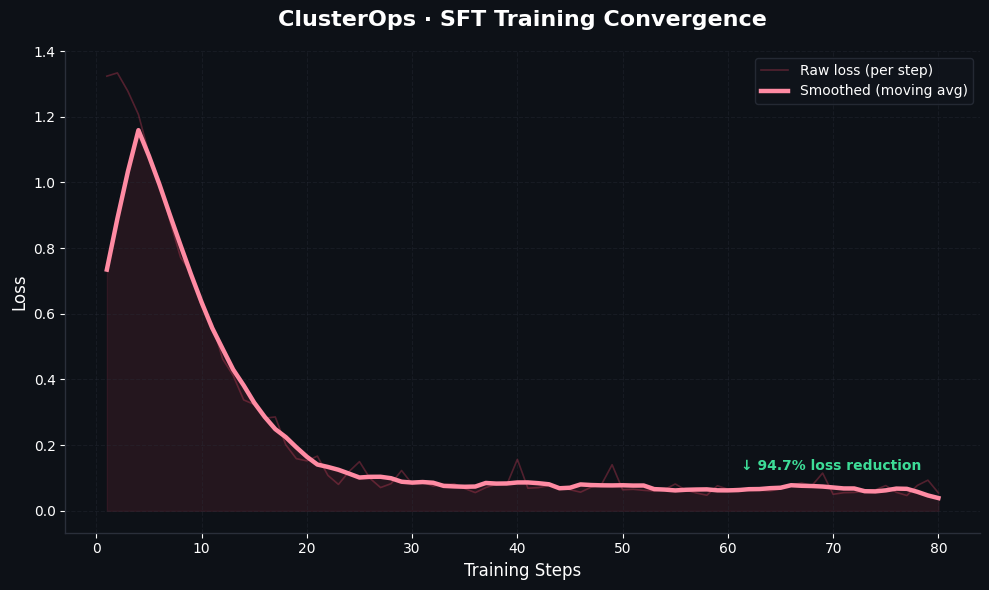

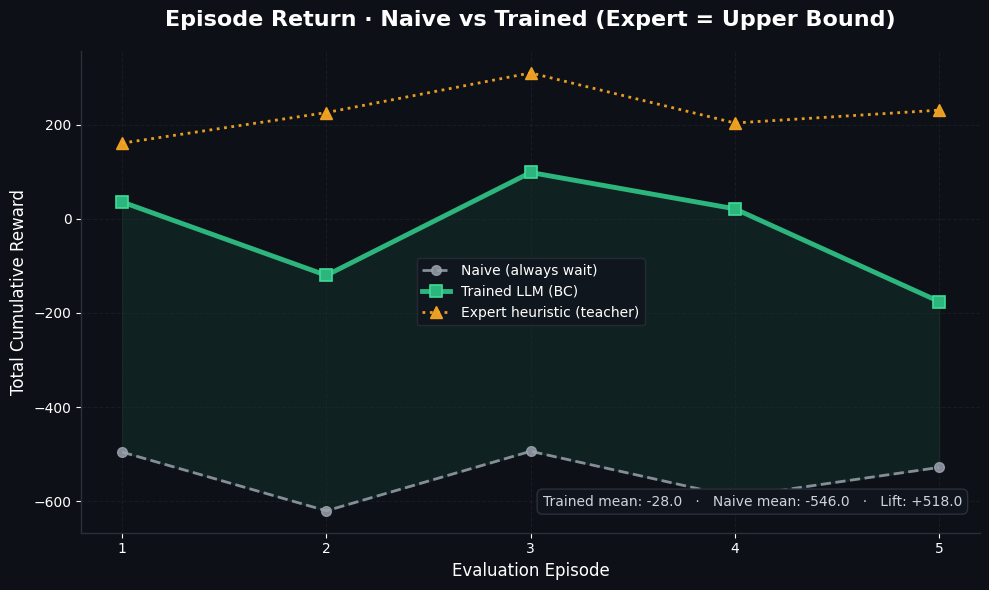

Saved:
  /content/clusterops_repo/assets/loss_curve.png
  /content/clusterops_repo/assets/reward_curve.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ASSETS_DIR = os.path.join(REPO_DIR, 'assets')
os.makedirs(ASSETS_DIR, exist_ok=True)

# Sleek dark palette
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titleweight': 'bold',
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'axes.edgecolor': '#2a2f3a',
    'axes.linewidth': 1.0,
    'axes.grid': True,
    'grid.color': '#2a2f3a',
    'grid.linestyle': '--',
    'grid.alpha': 0.35,
    'legend.frameon': True,
    'legend.facecolor': '#10141c',
    'legend.edgecolor': '#2a2f3a',
    'legend.fontsize': 10,
})

success_color = '#2cb67d'
trained_glow = '#3ddc97'
danger_color = '#ef4565'
loss_glow    = '#ff8ba3'
muted_color  = '#9aa1ad'
gold_color   = '#f5a623'
face         = '#0d1117'


def _despine(ax):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#2a2f3a')


def moving_average(y, window):
    y = np.asarray(y, dtype=float)
    if len(y) < 3:
        return y.copy()
    w = min(window, len(y) if len(y) % 2 == 1 else len(y) - 1)
    if w < 3:
        w = 3
    if w % 2 == 0:
        w -= 1
    kernel = np.ones(w) / w
    return np.convolve(y, kernel, mode='same')


paths_saved = []

# ── 1. Loss: raw + smoothed (sleek convergence curve) ────────────────────────
history = getattr(trainer.state, 'log_history', []) or []
loss_raw = [x['loss'] for x in history if 'loss' in x]
steps    = [x['step'] for x in history if 'loss' in x]

if loss_raw:
    loss_smooth = moving_average(loss_raw, window=7)

    fig, ax = plt.subplots(figsize=(10, 6), facecolor=face)
    ax.set_facecolor(face)
    ax.plot(steps, loss_raw, color=danger_color, linewidth=1.2, alpha=0.30, label='Raw loss (per step)')
    ax.plot(steps, loss_smooth, color=loss_glow, linewidth=3.2, label='Smoothed (moving avg)')
    ax.fill_between(steps, loss_smooth, alpha=0.10, color=danger_color)

    start, end = float(loss_smooth[0]), float(loss_smooth[-1])
    delta_pct = (start - end) / start * 100.0 if start > 0 else 0.0
    ax.annotate(
        f'↓ {delta_pct:.1f}% loss reduction',
        xy=(steps[-1], end), xytext=(-12, 18), textcoords='offset points',
        ha='right', va='bottom', fontsize=10, color=trained_glow, fontweight='bold',
    )

    ax.set_title('ClusterOps · SFT Training Convergence', pad=18)
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Loss')
    ax.legend(loc='upper right')
    _despine(ax)
    fig.tight_layout()

    loss_path = os.path.join(ASSETS_DIR, 'loss_curve.png')
    fig.savefig(loss_path, dpi=300, bbox_inches='tight', facecolor=face)
    plt.show()
    plt.close(fig)
    paths_saved.append(loss_path)
else:
    print('[warn] No loss history found — skipping loss curve.')

# ── 2. Episode Return: naive vs trained, expert as upper bound ───────────────
naive_arr   = np.asarray(naive_rewards,   dtype=float)
trained_arr = np.asarray(trained_rewards, dtype=float)
expert_arr  = np.asarray(expert_rewards,  dtype=float)

if trained_arr.size:
    ep_x = np.arange(1, trained_arr.size + 1)

    fig, ax = plt.subplots(figsize=(10, 6), facecolor=face)
    ax.set_facecolor(face)

    ax.plot(ep_x, naive_arr,   label='Naive (always wait)',
            linestyle='--', marker='o', color=muted_color, alpha=0.85, linewidth=2, markersize=7)
    ax.plot(ep_x, trained_arr, label='Trained LLM (BC)',
            color=success_color, marker='s', linewidth=3.5, markersize=9,
            markeredgecolor=trained_glow, markeredgewidth=1.2)
    ax.plot(ep_x, expert_arr,  label='Expert heuristic (teacher)',
            linestyle=':', marker='^', color=gold_color, linewidth=2, markersize=8, alpha=0.95)

    ax.fill_between(
        ep_x,
        np.minimum(naive_arr, trained_arr),
        np.maximum(naive_arr, trained_arr),
        color=success_color, alpha=0.10, label='_nolegend_',
    )

    naive_mean   = float(naive_arr.mean())
    trained_mean = float(trained_arr.mean())
    expert_mean  = float(expert_arr.mean())
    lift = trained_mean - naive_mean
    ax.text(
        0.98, 0.05,
        f'Trained mean: {trained_mean:.1f}   ·   Naive mean: {naive_mean:.1f}   ·   Lift: {lift:+.1f}',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=10, color='#cfd3dc',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#10141c', edgecolor='#2a2f3a'),
    )

    ax.set_title('Episode Return · Naive vs Trained (Expert = Upper Bound)', pad=18)
    ax.set_xlabel('Evaluation Episode')
    ax.set_ylabel('Total Cumulative Reward')
    ax.set_xticks(ep_x)
    ax.legend(loc='best')
    _despine(ax)
    fig.tight_layout()

    reward_path = os.path.join(ASSETS_DIR, 'reward_curve.png')
    fig.savefig(reward_path, dpi=300, bbox_inches='tight', facecolor=face)
    plt.show()
    plt.close(fig)
    paths_saved.append(reward_path)
else:
    print('[warn] No evaluation rewards found — skipping reward curve.')

if paths_saved:
    print('Saved:\n  ' + '\n  '.join(paths_saved))
    try:
        from google.colab import files
        for p in paths_saved:
            files.download(p)
    except Exception:
        pass